## CÉLULA 01
BASE DE DADOS E GRÁFICOS

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np


URL = (
    "https://github.com/cfneves/turma-visualizacao-de-dados/blob/master/alunos/jonatas_mag/Semana_04/base_rh.xlsx?raw=true"
)

df = pd.read_excel(URL)

df["Data_Admissao"] = pd.to_datetime(
    df["Data_Admissao"],
    format="%d/%m/%Y",
    errors="coerce"
)

print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas.")

Dataset carregado: 1000 linhas x 10 colunas.


## CÉLULA 02
1º OLHAR DOS DADOS

In [3]:
# print - A mostra
# df - DataFrame
# df.head() - Mostra as primeiras linhas do DataFrame
# df.tail() - Mostra as últimas linhas do DataFrame

#df.head(10) - Se não tiver a print, ele mostra as 5 primeiras linhas em Data Wrangler
#df.tail(10) - Se não tiver o print, ele mostra as 5 últimas linhas em Data Wrangler

df.head()  # Mostra as primeiras linhas em Data Wrangler

print(df.head())  # Mostra as primeiras linhas no terminal em pd


   ID_Funcionario                 Nome Departamento        Cargo   Salario  \
0               1          Julia Nunes    Logística  Coordenador   9088.34   
1               2   Sr. Gustavo Duarte           TI      Gerente   8155.98   
2               3  Srta. Mariana Cunha           RH  Coordenador  14027.93   
3               4   Ana Sophia da Cruz     Produção      Técnico   6647.97   
4               5    Dr. Nicolas Pinto     Produção      Gerente   8730.19   

  Data_Admissao Genero  Idade Estado_Civil   Status  
0    2024-08-13      F     43     Solteiro  Inativo  
1    2017-04-29      F     59     Solteiro  Inativo  
2    2024-12-11      F     27   Divorciado    Ativo  
3    2019-06-16      M     50       Casado  Inativo  
4    2019-03-29      F     62       Casado  Inativo  


## CÉLULA 03
EXPLORANDO A ESTRUTURA DO DATASET

In [2]:
print(df.tail())
print(df.columns)
print(df.info())
print(df.describe())


     ID_Funcionario                Nome Departamento     Cargo   Salario  \
995             996      Matheus Aragão   Financeiro  Analista  11389.03   
996             997        Ryan Martins   Financeiro  Analista  14060.42   
997             998   Isabelly Ferreira           TI   Gerente   2348.73   
998             999       Thales Farias     Produção  Analista   9430.62   
999            1000  Sra. Maysa Costela     Produção   Técnico  12549.72   

    Data_Admissao Genero  Idade Estado_Civil   Status  
995    2022-05-06      F     26        Viúvo    Ativo  
996    2023-06-05      F     37        Viúvo    Ativo  
997    2023-12-29      F     58     Solteiro  Inativo  
998    2019-12-25      M     41     Solteiro    Ativo  
999    2022-11-14      M     46        Viúvo  Inativo  
Index(['ID_Funcionario', 'Nome', 'Departamento', 'Cargo', 'Salario',
       'Data_Admissao', 'Genero', 'Idade', 'Estado_Civil', 'Status'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1000 entri

## CÉLULA 04 - SÉRIES
QUANDO SELECIONAMOS UMA COLUNA 

In [3]:
# df['Salário'] - Acessa a coluna 'Salário' do DataFrame
# df['Salário'].mean() - Calcula a média da coluna 'Salário'

salarios = df["Salario"]
media_salarios = salarios.mean()

print(f"Tipo  : {type(salarios)}")
print(f"shape : {salarios.shape}")
print(f"dtype : {salarios.dtype}")
print(salarios.head(5))

print(f"A média salarial é: {media_salarios:.2f}")
print("\n" + "--" * 38)

Tipo  : <class 'pandas.Series'>
shape : (1000,)
dtype : float64
0     9088.34
1     8155.98
2    14027.93
3     6647.97
4     8730.19
Name: Salario, dtype: float64
A média salarial é: 8579.95

----------------------------------------------------------------------------


## CÉLULA 05 - DATAFAME
SELECIONANDO DUAS OU MAIS COLUNAS

In [4]:
# DF[["Nome", "Salario"]] - Acessa as colunas 'Nome' e 'Salario' do DataFrame

sub = df[["Nome", "Salario"]]
print(f"\nTipo  : {type(sub)}")
print(f"shape : {sub.shape}")
print(f"dtype : {sub.dtypes}")
print(sub.head(5))

print("\n" + "--"*38)


Tipo  : <class 'pandas.DataFrame'>
shape : (1000, 2)
dtype : Nome           str
Salario    float64
dtype: object
                  Nome   Salario
0          Julia Nunes   9088.34
1   Sr. Gustavo Duarte   8155.98
2  Srta. Mariana Cunha  14027.93
3   Ana Sophia da Cruz   6647.97
4    Dr. Nicolas Pinto   8730.19

----------------------------------------------------------------------------


## CÉLULA 06 - ESTATÍSTICA BÁSICA
MÉDIA, MEDIANA, MINIMO E MÁXIMO

In [21]:
# :,.2F - Formata o número com vírgula como separador de milhar e 2 casas decimais
# Exemplo: 12500,00 vira 12.500,00

print(f"\nMédia   : {salarios.mean():,.2f}")
print(f"Mediana : {salarios.median():,.2f}")
print(f"Mínimo  : {salarios.min():,.2f}")
print(f"Máximo  : {salarios.max():,.2f}")


Média   : 8,579.95
Mediana : 8,571.13
Mínimo  : 2,000.71
Máximo  : 14,954.51


## CÉLULA 07 - HISTOGRAMA
COMO OS SALÁRIOS ESTÃO DISTRIBUÍDOS

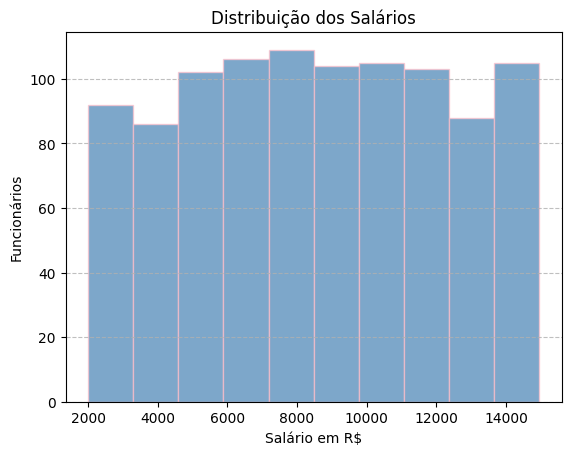

In [26]:
# Historiograma - Gráfico de barras para mostrar a distribuição dos salários
# X - Eixo horizontal (salários)
# Y - Eixo vertical (frequência)
# bins=10  # Número de barras no histograma

# Padrao de construção de um gráfico
# - plt.hist() - Cria um histograma
# - plt.title() - Adiciona um título ao gráfico
# - plt.xlabel() - Adiciona um rótulo ao eixo X
# - plt.ylabel() - Adiciona um rótulo ao eixo Y
# - plt.grid() - Adiciona uma grade ao gráfico
# - plt.show() - Exibe o gráfico

dados = np.random.normal(0, 1, 1000)
plt.hist(salarios, bins=10, color='steelblue', edgecolor='pink', alpha=0.7)
plt.title('Distribuição dos Salários')
plt.xlabel('Salário em R$')
plt.ylabel('Funcionários')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.show()


## O QUE TEMOS NESSE GRÁFICO?
1 - CADA BARRA, UMA FAIXA DE SALÁRIO<br>
2 - A ALTURA, QTY DE FUNCIONÁRIOS<br>
3 - A BASE "X", OS SALÁRIOS - DO MENOR P/ O MAIOR<br>

## CÉLULA 08 - ÍNDICES
O "ENDEREÇO" DE CADA LINHA

In [5]:
# Indice - Padrão do pd para acessar os dados por linha: 0, 1, 2, ...
# set_index() - Define a coluna ID_Funcionario como índice do DataFrame
# Usa-se o termo df_idx_loc[] - Para acessar os dados usando o índice definido
# reset_index() - Volta para o índice padrão do DataFrame
# O (df[df["Status"] == "Ativo"]) - Filtra o DataFrame pelo índice original para mostrar apenas os funcionários ativos

print("Índece padrão:", df.index)

df_idx = df.set_index("ID_Funcionario")
print("\nÍndice redefinido:", df_idx.index)

print("\nFuncionário ID=5:") 
print(df_idx.loc[5][["Nome", "Departamento", "Salario"]])

df_volta = df_idx.reset_index()
print(f"\nÍndice resetado: {df_volta.index}")

ativos = df[df["Status"] == "Ativo"]
print(f"\nFuncionários ativos            : {ativos.index[0]}")
print(f"Total de funcionários ativos   : {len(ativos)}")
print(f"Total de funcionários inativos : {len(df) - len(ativos)}")


Índece padrão: RangeIndex(start=0, stop=1000, step=1)

Índice redefinido: RangeIndex(start=1, stop=1001, step=1, name='ID_Funcionario')

Funcionário ID=5:
Nome            Dr. Nicolas Pinto
Departamento             Produção
Salario                   8730.19
Name: 5, dtype: object

Índice resetado: RangeIndex(start=0, stop=1000, step=1)

Funcionários ativos            : 2
Total de funcionários ativos   : 515
Total de funcionários inativos : 485


## CÉLULA 09 - GRÁFICOS DE BARRA
COMPARANDO CATEGORIAS

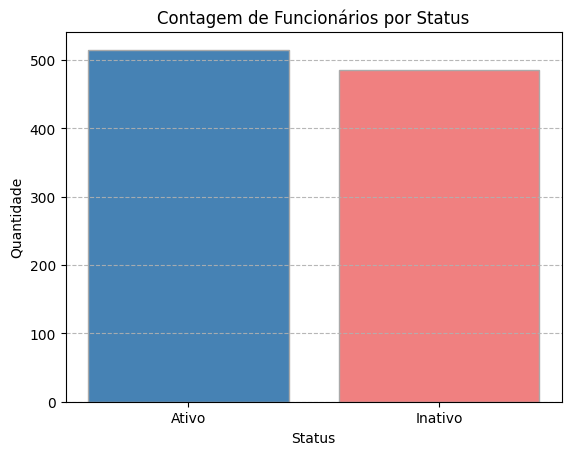

In [14]:
# Padrão de Calcular primeiro e plotar depois
# 1 - df["Status"].value_couts() - Conta a frequência de cada valor na coluna 'Status'
# 2 - plt.bar(contagem.index, contagem.values) - Cria um gráfico de barras usando os índices e valores da contagem
# 3 - index = rotulo "X"
# 4 - value = quantidade "Y" (Altura)

# Calculo do que vamos mostrar no gráfico
contagem = df["Status"].value_counts()

plt.bar(contagem.index, contagem.values, edgecolor='darkgray', color=['steelblue', 'lightcoral'])
plt.title('Contagem de Funcionários por Status')
plt.xlabel('Status')
plt.ylabel('Quantidade')
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.show()


## CÉLULA 10 - CATEGORIA
ECONOMIA DE MEMORIA E ORGANIZAÇÃO DE DADOS

In [16]:
# Tipo: category - permite ordenação personalizada
# Libera o acessor .cat para manipular os dados categóricos com métodos específicos
# O for col in [lista]: - é um laço que percorre cada nome de lista para converção automática
# O .cat.categories - Mostra as categorias únicas da coluna categórica

# Convertendo as colunas
for col in ["Departamento", "Cargo", "Genero", "Estado_Civil", "Status"]:
    df[col] = df[col].astype('category')

print("Tipos após conversão:")
print(df.dtypes)

print(f"\nDepartamento: {df['Departamento'].cat.categories.tolist()}")
print(f"Cargo       : {df['Cargo'].cat.categories.tolist()}")

print("\nFuncionários por departamento:")
print(df["Departamento"].value_counts())


Tipos após conversão:
ID_Funcionario             int64
Nome                         str
Departamento            category
Cargo                   category
Salario                  float64
Data_Admissao     datetime64[us]
Genero                  category
Idade                      int64
Estado_Civil            category
Status                  category
dtype: object

Departamento: ['Financeiro', 'Logística', 'Produção', 'RH', 'TI', 'Vendas']
Cargo       : ['Analista', 'Assistente', 'Coordenador', 'Gerente', 'Técnico']

Funcionários por departamento:
Departamento
Financeiro    189
Produção      182
RH            166
Vendas        160
Logística     156
TI            147
Name: count, dtype: int64


## CÉLULA 11 - BARRAS HORIZONTAIS
QUANDO OS RÓTULOS SÃO LONGOS

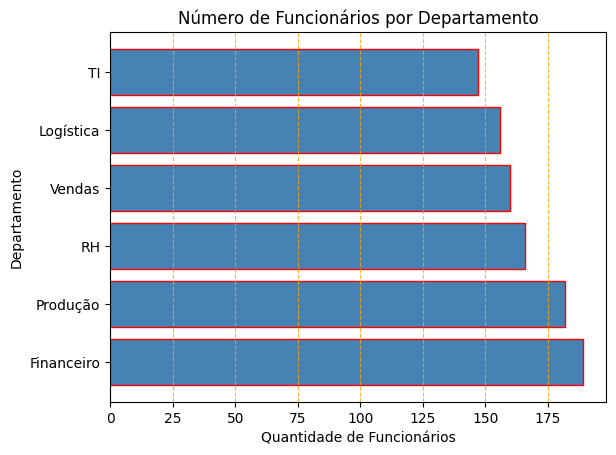

In [32]:
# plt.barh() - Horizontal e plt.bar() - Vertical

dist = df["Departamento"].value_counts()

plt.barh(dist.index, dist.values, edgecolor='red', color='steelblue')
plt.title('Número de Funcionários por Departamento')
plt.xlabel('Quantidade de Funcionários')
plt.ylabel('Departamento')
plt.grid(axis='x', linestyle='--', alpha=0.8, color='orange')
plt.show()

## CÉLULA 12 - iloc
SELEÇÃO POR POSIÇÃO NUMÉRICA

In [3]:
# iloc vs loc - iloc = posição numérica e loc = rótulo do índice
print("Primeira linha (iloc[0]):")
print(df.iloc[0][["Nome", "Departamento", "Salario"]])

# Slice de linhas e colunas (posição 2, 3, 4 - coluna 1, 2, 3)
print("\niloc[2:5, 1:4]:")
print(df.iloc[2:5, 1:4].to_string())

# Última linha
print(f"\nÚltima linha - Nome: {df.iloc[-1]['Nome']}")

# Lista de posições específicas
amostra = df.iloc[[0, 99, 499, 999], [0, 1, 4]]
print("\nAmostra (posição 0, 99, 499, 999):")
print(amostra.to_string())


Primeira linha (iloc[0]):
Nome            Julia Nunes
Departamento      Logística
Salario             9088.34
Name: 0, dtype: object

iloc[2:5, 1:4]:
                  Nome Departamento        Cargo
2  Srta. Mariana Cunha           RH  Coordenador
3   Ana Sophia da Cruz     Produção      Técnico
4    Dr. Nicolas Pinto     Produção      Gerente

Última linha - Nome: Sra. Maysa Costela

Amostra (posição 0, 99, 499, 999):
     ID_Funcionario                Nome   Salario
0                 1         Julia Nunes   9088.34
99              100    Helena Gonçalves  13896.74
499             500     Nicolas Rezende   2799.98
999            1000  Sra. Maysa Costela  12549.72


## CÉLULA 13 - HISTOGRAMA DE IDADE
PRATICANDO O CONCEITO

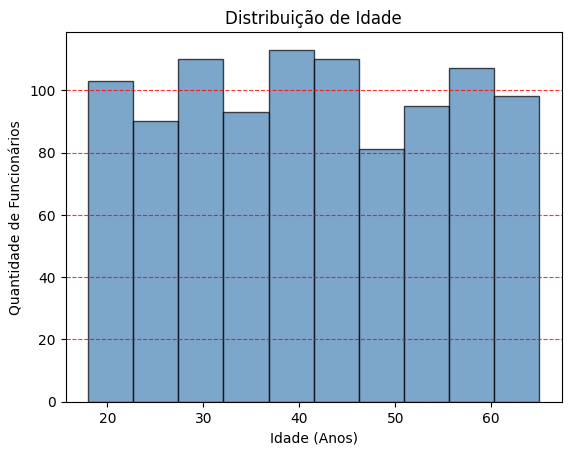

In [30]:
plt.hist(df["Idade"], bins=10, color="steelblue", edgecolor="black", alpha=0.7)
plt.title("Distribuição de Idade")
plt.xlabel("Idade (Anos)")
plt.ylabel("Quantidade de Funcionários")
plt.grid(axis='y', linestyle='--', alpha=0.8, color='red')
plt.show()

### O QUE ESTE GRÁFICO MOSTRA?

A **distribuição das idades** dos funcionários. Cada barra agrupa aproximadamente 5 anos e mostra quantas pessoas estão naquela faixa etária.

## CÉLULA 14 - loc
SELEÇÃO POR RÓTULO E FILTROS BOOLEANOS

##### **Sintaxe:** - df.loc[condição_de_linha, ["col1", "col2"]]
**Operadores para combinar condições:**
- `&` → E (as duas precisam ser verdadeiras)
- `|` → OU (pelo menos uma precisa ser verdadeira)
- `~` → NÃO (inverte o resultado)

In [14]:
# 1 - Por indice e nome de coluna
print("linha 0, coluna Nome:", df.loc[0, "Nome"])

# 2 - Condição Booleana
producao = df.loc[
    df["Departamento"] == "Produção",
    ["Nome", "Cargo", "Salario"]
]
print(f"\nProdução: {len(producao)} funcionários (os 5 primeiros):")
print(producao.head(5).to_string(index=False))

# 3 - Multiplas condições
lideranca = df.loc[
    (df["Departamento"] == "Produção") &
    (df["Cargo"].isin(["Gerente", "Coordenador"])),
    ["Nome", "Cargo", "Salario", "Status"]
]
print(f"\n Liderança de Produção: {len(lideranca)}")
print(lideranca.to_string(index=False))

# 4 - Criando colunas de forma segura
df.loc[df["Salario"] >= 10000, "Faixa_Salarial"] = "Senior/Especialista"
df.loc[df["Salario"] < 10000, "Faixa_Salarial"] = "Pleno/Junior"
print("\nFaixa Salaarial:")
print(df["Faixa_Salarial"].value_counts())


linha 0, coluna Nome: Julia Nunes

Produção: 182 funcionários (os 5 primeiros):
                 Nome   Cargo  Salario
   Ana Sophia da Cruz Técnico  6647.97
    Dr. Nicolas Pinto Gerente  8730.19
 João Miguel da Costa Técnico  4771.89
  Davi Lucca Teixeira Gerente 13512.53
Maria Julia das Neves Técnico 11440.30

 Liderança de Produção: 83
                      Nome       Cargo  Salario  Status
         Dr. Nicolas Pinto     Gerente  8730.19 Inativo
       Davi Lucca Teixeira     Gerente 13512.53   Ativo
      Srta. Giovanna Pinto Coordenador  2503.83 Inativo
            Lorenzo Campos     Gerente 10022.05   Ativo
             Cauã Monteiro Coordenador  6495.75 Inativo
                Luna Silva Coordenador  3912.77 Inativo
               Isaac Lopes Coordenador  2297.43   Ativo
            Marina Ribeiro Coordenador  6106.47   Ativo
          Mirella da Costa     Gerente 14460.59   Ativo
         Anthony das Neves     Gerente 10523.68   Ativo
          Fernanda Almeida     Gerente 149

## CÉLULA 15 - groupby
CALCULANDO MÉTRICAS POR GRUPO

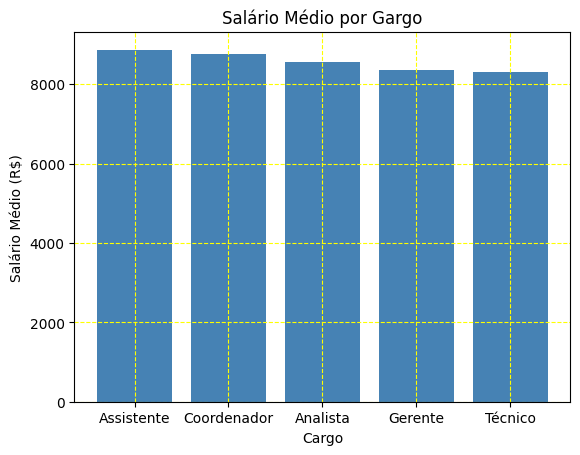

In [ ]:
# O groupby segue a seguinte lógica:
# 1 - Divide: Divide o DatFrame em grupo
# 2 - Aplica: Uma função para cada grupo - mean()
# 3 - Combina: Os resultados em uma nova Série

# **Exe.: df.groupby("cargo")["Salario"].mean()
# .sort_values(ascending=False) - Organiza do maior para o menor

media_cargo = df.groupby("Cargo")["Salario"].mean().sort_values(ascending=False)

plt.bar(media_cargo.index, media_cargo.values, color="steelblue")
plt.title("Salário Médio por Gargo")
plt.xlabel("Cargo")
plt.ylabel("Salário Médio (R$)")
plt.grid(color='yellow', linestyle='-' '-')
plt.show()



## CÉLULA 16
FILTROS EXPRESSIVOS

In [ ]:
# **`query()`** — sintaxe parecida com SQL, fácil de ler em voz alta
# df.query("Salario > 8000 and Status == 'Ativo'")
# Use `@variavel` para referenciar uma variável Python dentro da string.

# **`isin(lista)`** — "está dentro desta lista de valores"
# df.loc[df["Cargo"].isin(["Gerente", "Coordenador"])]
# equivale a: Cargo == "Gerente" | Cargo == "Coordenador"

# **`between(min, max)`** — filtra por intervalo fechado (inclui os extremos)
# df.loc[df["Idade"].between(30, 45)]
# equivale a: Idade >= 30 & Idade <= 45

In [76]:
# query() - Básico
resultado = df.query("Salario > 8000 and Status == 'Ativo'")
print(f"Todos os Ativos com Salário > R$ 8.000,00: {len(resultado)}")

# query() - Com variável externo - prefixo @
sal_min = 8500
deptos = ["Produca", "Logistica", "Técnico"]
res2 = df.query("Salario >= @sal_min and Departamento in @deptos")
print(f"\nPorducao/Logistica >= R$ {sal_min:,}: {len(res2)}")

# isin() - Filtrar por lista de valores
lideranca = df.loc[df["Cargo"].isin(["Gerente", "Coordenador", "Técnico"])]
print(f"Total de líderes: {len(lideranca)}")
print(lideranca.groupby("Cargo")["Salario"].agg(["count", "mean"]).round(2))

# between() - Filtrar por interválos extremos incluidos
faixa = df.loc[df["Idade"].between(30, 45)]
print(f"\nFuncionarios de 30-45 anos: {len(faixa)}")
print(f"Salário Médio             : R$ {faixa['Salario'].mean():,.2f}")

Todos os Ativos com Salário > R$ 8.000,00: 287

Porducao/Logistica >= R$ 8,500: 0
Total de líderes: 623
             count     mean
Cargo                      
Coordenador    225  8763.86
Gerente        221  8363.46
Técnico        177  8308.26

Funcionarios de 30-45 anos: 350
Salário Médio             : R$ 8,817.64


## CÉLULA 17 - GRÁFICO DE PIZZA
PARTES DE UM TODO

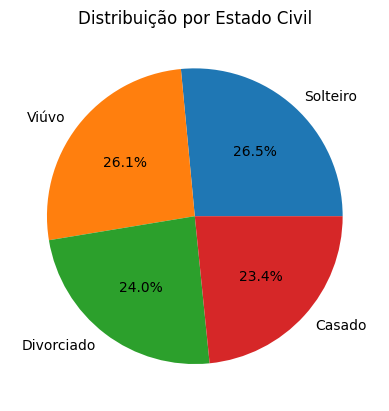

In [89]:
# autopct="%1.1f%%" - Adicionar automaticamente o percentual em cada fatia com 1 casa decimal
# Usar PIZZA quando as fatias somam 100% e para enfatizar a proporção relativa

estado = df["Estado_Civil"].value_counts()

plt.pie(estado.values, labels=estado.index, autopct="%1.1f%%")
plt.title("Distribuição por Estado Civil")
plt.show()

## CÉLULA 18 - EXERCÍCIO PRÁTICO
COMBINANDO MULTIPLOS FILTROS

In [95]:
# "Selecione as linhas onde Departamento é TI **E** Status é Ativo **E** Cargo está entre Gerente e Coordenador. Mostre Nome, Cargo, Salario e Data_Admissao."
# `.sort_values("Salario", ascending=False)` ordena o resultado do maior para o menor salário.

lideranca_ti = df.loc[
    (df["Departamento"] == "TI") &
    (df["Status"] == "Ativo") &
    (df["Cargo"].isin(["Gerente", "Coordenador", "Técnico"])),
    ["Nome", "Cargo", "Salario", "Data_Admissao"]
].sort_values(["Cargo", "Salario", "Data_Admissao"], ascending=False)

print(f"Lideres de TI ativos: {len(lideranca_ti)}")
print(lideranca_ti.to_string(index=False))

Lideres de TI ativos: 41
                       Nome       Cargo  Salario Data_Admissao
   Sra. Maria Vitória Pires     Técnico 13628.87    2023-11-07
          Dr. Benjamin Lima     Técnico 13621.22    2023-07-03
      Maria Sophia Carvalho     Técnico 12350.47    2017-02-10
  Dra. Maria Alice Oliveira     Técnico 12258.99    2016-10-20
       Sr. Antônio Silveira     Técnico 10544.85    2018-02-21
            Sr. Diego Gomes     Técnico  9866.58    2017-07-20
            Dr. André Ramos     Técnico  8037.41    2022-09-05
             Eloah Oliveira     Técnico  4784.12    2015-09-26
         Marcela Cavalcanti     Técnico  4142.55    2016-08-05
          Sr. Breno da Mata     Técnico  4024.83    2021-02-09
               Thales Moura     Técnico  3575.64    2025-07-14
             Joaquim da Paz     Técnico  2013.79    2021-12-11
          Ana Clara Moreira     Gerente 14523.10    2025-01-06
              Bryan da Cruz     Gerente 11790.21    2021-02-08
               Stella Costa   

## CÉLULA 19
FAIXAS SALARIAIS DETALHADAS

In [96]:
df.loc[df["Salario"] >  12000, "Faixa_Salarial"] = "Especialista"
df.loc[df["Salario"].between(8001, 12000), "Faixa_Salarial"] = "Senior"
df.loc[df["Salario"].between(4001,  8000), "Faixa_Salarial"] = "Pleno"
df.loc[df["Salario"] <= 4000, "Faixa_Salarial"] = "Junior"

print(df["Faixa_Salarial"].value_counts())

Faixa_Salarial
Senior          328
Pleno           320
Especialista    220
Junior          132
Name: count, dtype: int64


## CÉLULA 20 - MÉDIA SALARIAL POR DP
groupby() + VISUALIZAÇÃO

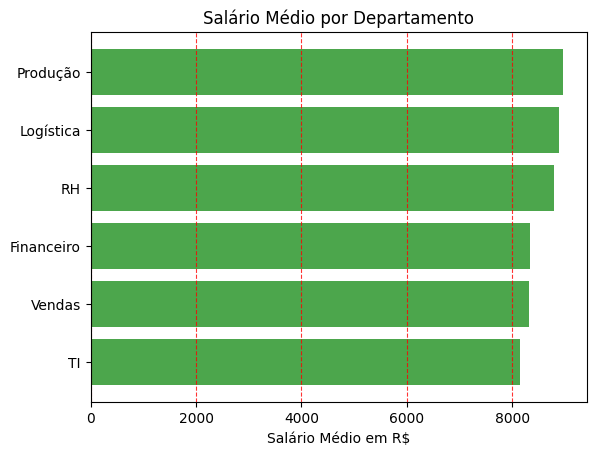

In [98]:
# Combinamos tudo que aprendemos em um único fluxo:
## 1. `groupby("Departamento")` → divide por departamento
## 2. `["Salario"].mean()` → calcula a média salarial de cada um
## 3. `.round(2)` → arredonda para 2 casas decimais
## 4. `.sort_values()` → ordena do menor para o maior (natural em barras horizontais, onde o maior fica no topo)
## 5. `plt.barh()` → visualiza o resultado

# Repare no padrão que se repete em toda a aula: **calcular → guardar em variável → plotar**.

media_depto = (
    df.groupby("Departamento")["Salario"].mean().round(2).sort_values()
)

plt.barh(media_depto.index, media_depto.values, color="green", alpha=0.7)
plt.title("Salário Médio por Departamento")
plt.xlabel("Salário Médio em R$")
plt.grid(axis='x', linestyle='--', alpha=0.8, color='red')
plt.show()


## Célula 21 — Pizza das faixas salariais:
Encerranento da aula 01

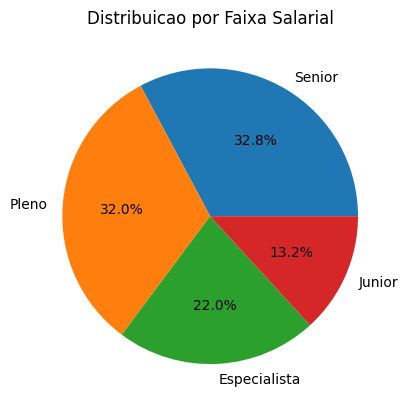

In [99]:
faixas = df["Faixa_Salarial"].value_counts()

# Plotar
plt.pie(faixas.values, labels=faixas.index, autopct="%1.1f%%")
plt.title("Distribuicao por Faixa Salarial")
plt.show()

#### Parabéns! Nesta aula você aprendeu a:
- Importar e carregar dados com pandas
- Explorar um DataFrame com os principais métodos (`head`, `info`, `describe`)
- Entender a diferença entre **Series** e **DataFrame**
- Selecionar dados por posição com **`iloc`** e por rótulo com **`loc`**
- Filtrar com condições booleanas, `query()`, `isin()` e `between()`
- Agrupar dados com **`groupby`**
- Criar **histogramas**, **gráficos de barras** e **pizza** com matplotlib